# EDA - Alojamientos Turísticos (StaySpain)

**Equipo:** Equip_34
**Fecha:** 13/07/2026
**Dataset:** raw_dataset_13_07_2026.csv

Este notebook cubre únicamente el **EDA general** del dataset:
dimensiones, tipos de datos, nulos, duplicados, estadísticas
descriptivas, distribuciones, boxplots, posibles valores atípicos y
correlaciones generales.

Las preguntas de negocio específicas de cada perfil (marketing,
operaciones y experiencia del cliente) se desarrollan en notebooks
individuales.

> **Nota:** Los tratamientos realizados aquí —por ejemplo, el parseo
> temporal de fechas— se utilizan únicamente para explorar los datos.
> La limpieza y transformación oficiales se documentan en las fases de
> Data Cleaning y Data Transformation, y no se guardan desde este
> notebook.


## 1. Carga de datos e importación de librerías

In [1]:
# Librerías básicas para EDA
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo simple para los gráficos
sns.set_style("whitegrid")


In [2]:
# Parámetros de ejecución: actualizar solo esta sección cuando cambie el dataset
DATASET_FILE = "raw_dataset_06_07_2026.csv"
FECHA_EDA = pd.Timestamp.today().strftime("%d/%m/%Y")


def encontrar_raiz_proyecto(nombre_carpeta="Equip_34"):
    """Busca la carpeta raíz del proyecto desde el directorio actual."""
    actual = Path.cwd()

    for carpeta in [actual] + list(actual.parents):
        if carpeta.name == nombre_carpeta:
            return carpeta

    raise FileNotFoundError(
        f"No se encontró la carpeta '{nombre_carpeta}' "
        f"subiendo desde {actual}"
    )


raiz_proyecto = encontrar_raiz_proyecto("Equip_34")
ruta_csv = raiz_proyecto / "Data" / DATASET_FILE

if not ruta_csv.exists():
    raise FileNotFoundError(f"No se encontró el dataset: {ruta_csv}")

print(f"Fecha de ejecución: {FECHA_EDA}")
print(f"Dataset: {DATASET_FILE}")
print(f"Ruta resuelta: {ruta_csv}")

df = pd.read_csv(ruta_csv)
df.head()


Fecha de ejecución: 14/07/2026
Dataset: raw_dataset_06_07_2026.csv
Ruta resuelta: /Users/naktasamipoor/Documents/1-work/business/Data analysis/8-Simulador/ProjecteData/Equip_34/Data/raw_dataset_06_07_2026.csv


,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,occupancy_30,occupancy_rate_30,occupancy_60,occupancy_rate_60,occupancy_90,occupancy_rate_90,occupancy_365,occupancy_rate_365,is_instant_bookable_numeric,has_availability_numeric
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,NaN,Private room,2,2.0,1.0,...,23,76.67,40,66.67,50,55.56,235,64.38,0,1.0
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1.0,1.0,...,30,100.00,60,100.00,90,100.00,203,55.62,0,1.0
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1.0,2.0,...,4,13.33,29,48.33,59,65.56,95,26.03,1,1.0
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,l'Antiga Esquerra de l'Eixample,Eixample,Private room,2,2.0,1.0,...,21,70.00,37,61.67,41,45.56,65,17.81,1,1.0
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,NaN,Private room,5,1.0,2.0,...,30,100.00,41,68.33,41,45.56,53,14.52,0,1.0


## 2. Visión general del dataset

In [3]:
# Dimensiones del dataset: filas x columnas
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])


Filas: 8000
Columnas: 46


In [4]:
# Tipos de datos de cada columna
df.dtypes


apartment_id                     int64
name                               str
description                        str
host_id                          int64
neighbourhood_name                 str
neighbourhood_district             str
room_type                          str
accommodates                     int64
bathrooms                      float64
bedrooms                       float64
beds                           float64
amenities_list                     str
price                          float64
minimum_nights                   int64
maximum_nights                   int64
has_availability                   str
availability_30                  int64
availability_60                  int64
availability_90                  int64
availability_365                 int64
number_of_reviews                int64
first_review_date                  str
last_review_date                   str
review_scores_rating           float64
review_scores_accuracy         float64
review_scores_cleanliness

Recordatorio (Data Understanding): `first_review_date`,
`last_review_date` e `insert_date` pueden llegar como texto en
formato `dd/mm/yyyy` o `yyyy-mm-dd`. Para poder explorarlas como fechas
se convierten aquí de manera temporal, sin sobrescribir el CSV
original.


In [5]:
# Conversión robusta de fechas para los formatos esperados
def convertir_fecha(serie):
    """Convierte fechas ISO o dd/mm/yyyy sin modificar el CSV original."""
    texto = serie.astype("string")
    resultado = pd.Series(pd.NaT, index=serie.index, dtype="datetime64[ns]")

    mascara_iso = texto.str.match(r"^\d{4}-\d{2}-\d{2}$", na=False)

    resultado.loc[mascara_iso] = pd.to_datetime(
        texto.loc[mascara_iso],
        format="%Y-%m-%d",
        errors="coerce",
    )
    resultado.loc[~mascara_iso] = pd.to_datetime(
        texto.loc[~mascara_iso],
        format="%d/%m/%Y",
        errors="coerce",
    )

    return resultado


for columna_fecha in [
    "first_review_date",
    "last_review_date",
    "insert_date",
]:
    df[columna_fecha] = convertir_fecha(df[columna_fecha])


In [6]:
# Rango temporal de insert_date (cuándo se registró cada anuncio)
print("Fecha más antigua:", df["insert_date"].min())
print("Fecha más reciente:", df["insert_date"].max())


Fecha más antigua: 2017-01-04 00:00:00
Fecha más reciente: 2021-02-27 00:00:00


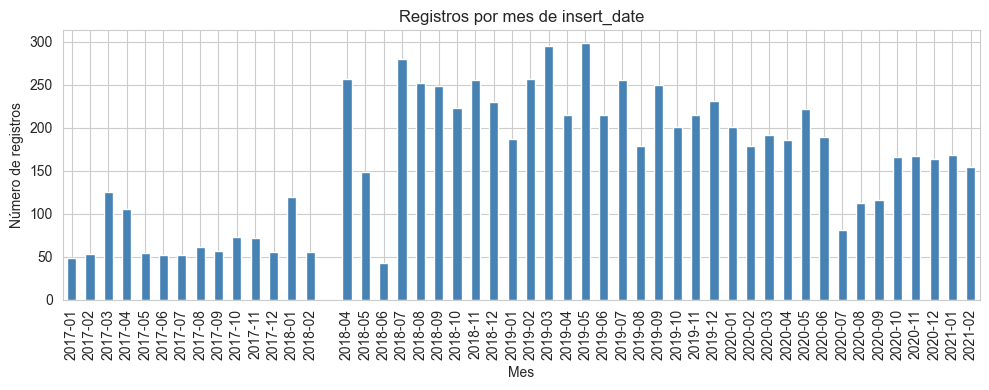

In [7]:
# Distribución temporal de insert_date (nº de registros por mes)
df["insert_date"].dt.to_period("M").value_counts().sort_index().plot(
    kind="bar", figsize=(10, 4), color="steelblue"
)
plt.title("Registros por mes de insert_date")
plt.xlabel("Mes")
plt.ylabel("Número de registros")
plt.tight_layout()
plt.show()


In [8]:
# Número de valores nulos por columna, ordenado de mayor a menor
nulos = df.isnull().sum().sort_values(ascending=False)
nulos[nulos > 0]


neighbourhood_district         3139
review_scores_value            1711
review_scores_location         1711
review_scores_checkin          1710
review_scores_accuracy         1705
review_scores_communication    1701
review_scores_cleanliness      1699
review_scores_rating           1696
rating_above_80                1696
last_review_date               1615
reviews_per_month              1614
first_review_date              1614
has_availability                550
has_availability_numeric        550
price                           171
description                      54
bathrooms                        43
bedrooms                         39
amenities_list                   17
beds                              8
name                              3
dtype: int64

In [9]:
# Porcentaje de nulos sobre el total de filas
pct_nulos = (nulos[nulos > 0] / len(df) * 100).round(2)
pct_nulos


neighbourhood_district         39.24
review_scores_value            21.39
review_scores_location         21.39
review_scores_checkin          21.38
review_scores_accuracy         21.31
review_scores_communication    21.26
review_scores_cleanliness      21.24
review_scores_rating           21.20
rating_above_80                21.20
last_review_date               20.19
reviews_per_month              20.18
first_review_date              20.18
has_availability                6.88
has_availability_numeric        6.88
price                           2.14
description                     0.68
bathrooms                       0.54
bedrooms                        0.49
amenities_list                  0.21
beds                            0.10
name                            0.04
dtype: float64

`neighbourhood_district` sigue siendo el campo con más nulos
(alto porcentaje), y `has_availability` mantiene el bloque de
~550 nulos ya detectado en Data Understanding (pendiente de
revisión con IT).


In [10]:
# Duplicados: filas 100% idénticas
duplicados_totales = df.duplicated().sum()
print("Filas totalmente duplicadas:", duplicados_totales)

# Duplicados por apartment_id (mismo alojamiento, otra fila)
duplicados_id = df["apartment_id"].duplicated().sum()
print("apartment_id duplicados:", duplicados_id)


Filas totalmente duplicadas: 0
apartment_id duplicados: 307


Los `apartment_id` repetidos no son errores: corresponden a
**snapshots** del mismo alojamiento capturados en distintas
fechas (`insert_date` distinto para cada copia, ver ejemplo
abajo). Es decir, un mismo anuncio puede aparecer varias veces
porque el dataset se ha actualizado en varios momentos.

Para los análisis posteriores (incluidas las preguntas de
negocio en los notebooks individuales) se utilizará **el
registro más reciente de cada alojamiento** (último
`insert_date` por `apartment_id`), de forma que cada anuncio
cuente una sola vez.


In [11]:
# Ejemplo de snapshots del mismo alojamiento en distintas fechas
id_ejemplo = df["apartment_id"].value_counts().index[0]
columnas_ver = ["apartment_id", "insert_date", "price",
                "availability_365"]

df[df["apartment_id"] == id_ejemplo][columnas_ver]


,apartment_id,insert_date,price,availability_365
1910,10005342,2018-07-10,310.0,246
1911,10005342,2018-09-11,310.0,241
1912,10005342,2019-05-14,300.0,282


In [12]:
# Estadísticas descriptivas de las variables numéricas clave:
# precio, capacidad, disponibilidad y valoraciones
columnas_num = [
    "price", "accommodates", "bathrooms", "bedrooms", "beds",
    "minimum_nights", "maximum_nights", "number_of_reviews",
    "availability_30", "availability_60",
    "availability_90", "availability_365",
    "review_scores_rating", "review_scores_accuracy",
    "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location",
    "review_scores_value",
]
df[columnas_num].describe()


,price,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,number_of_reviews,availability_30,availability_60,availability_90,availability_365,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,7829.000000,8000.00000,7957.000000,7961.000000,7992.000000,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,6304.000000,6295.000000,6301.000000,6290.000000,6299.000000,6289.00000,6289.000000
mean,1007.751182,4.32700,1.598969,1.953147,2.971346,4.57125,761.230125,31.361750,12.391250,27.606750,44.599500,188.335875,91.969860,9.455759,9.316299,9.627822,9.635339,9.53204,9.140881
std,844.347373,2.59199,0.983736,1.290257,2.289586,11.80783,497.949602,57.083552,11.524301,22.408266,32.996787,129.643586,8.906715,0.924152,0.996392,0.803844,0.793289,0.75072,0.963651
min,60.000000,1.00000,0.000000,0.000000,0.000000,1.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000
25%,450.000000,2.00000,1.000000,1.000000,1.000000,1.00000,62.000000,1.000000,0.000000,2.000000,9.000000,67.000000,89.000000,9.000000,9.000000,9.000000,9.000000,9.00000,9.000000
50%,750.000000,4.00000,1.000000,2.000000,2.000000,2.00000,1125.000000,8.000000,10.000000,27.000000,47.000000,190.000000,94.000000,10.000000,10.000000,10.000000,10.000000,10.00000,9.000000
75%,1220.000000,6.00000,2.000000,3.000000,4.000000,4.00000,1125.000000,36.000000,24.000000,50.000000,76.000000,316.000000,98.000000,10.000000,10.000000,10.000000,10.000000,10.00000,10.000000
max,6071.000000,29.00000,12.000000,16.000000,30.000000,365.00000,1125.000000,588.000000,30.000000,60.000000,90.000000,365.000000,100.000000,10.000000,10.000000,10.000000,10.000000,10.00000,10.000000


In [13]:
# Estadísticas descriptivas de las variables categóricas
# (count, valores únicos, valor más frecuente y su frecuencia)
columnas_categoricas = [
    "city", "country", "room_type",
    "neighbourhood_district",
    "is_instant_bookable", "has_availability",
]

df[columnas_categoricas].describe()

,city,country,room_type,neighbourhood_district,is_instant_bookable,has_availability
count,8000,8000,8000,4861,8000,7450
unique,8,1,4,61,2,1
top,barcelona,spain,Entire home/apt,Centro,VERDADERO,VERDADERO
freq,2358,8000,5680,871,4439,7450


### 2.1 Revisión general de asimetría y posibles valores atípicos

La regla IQR se utiliza aquí únicamente como una señal exploratoria.
Los valores identificados no se eliminan automáticamente: deberán
validarse en Data Cleaning considerando el contexto y el significado
de cada variable.


In [14]:
# Selección automática de variables numéricas, excluyendo identificadores
columnas_numericas_eda = [
    columna
    for columna in df.select_dtypes(include="number").columns
    if columna not in {"apartment_id", "host_id"}
]


def resumen_outliers_iqr(dataframe, columnas):
    """Resume asimetría y posibles valores atípicos según la regla IQR."""
    resultados = []

    for columna in columnas:
        serie = dataframe[columna].dropna()

        if serie.empty:
            continue

        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        mascara_outlier = (
            (serie < limite_inferior)
            | (serie > limite_superior)
        )
        posibles_outliers = int(mascara_outlier.sum())

        resultados.append({
            "variable": columna,
            "asimetria": serie.skew(),
            "limite_inferior_iqr": limite_inferior,
            "limite_superior_iqr": limite_superior,
            "posibles_outliers": posibles_outliers,
            "porcentaje_outliers": posibles_outliers / len(serie) * 100,
        })

    return pd.DataFrame(resultados).round(2)


resumen_atipicos = resumen_outliers_iqr(df, columnas_numericas_eda)

resumen_atipicos.sort_values(
    ["porcentaje_outliers", "asimetria"],
    ascending=[False, False],
).reset_index(drop=True)


,variable,asimetria,limite_inferior_iqr,limite_superior_iqr,posibles_outliers,porcentaje_outliers
0,number_of_reviews,3.56,-51.50,88.50,827,10.34
1,price,2.07,-705.00,2375.00,597,7.63
2,reviews_per_month,1.96,-229.00,427.00,397,6.22
3,minimum_nights,15.95,-3.50,8.50,447,5.59
4,bathrooms,2.80,-0.50,3.50,377,4.74
5,review_scores_value,-2.25,7.50,11.50,264,4.20
6,review_scores_rating,-2.83,75.50,111.50,254,4.03
7,review_scores_cleanliness,-2.71,7.50,11.50,251,3.98
8,review_scores_accuracy,-3.16,7.50,11.50,190,3.02
9,beds,2.18,-3.50,8.50,183,2.29


## 3. Distribuciones y boxplots de variables representativas

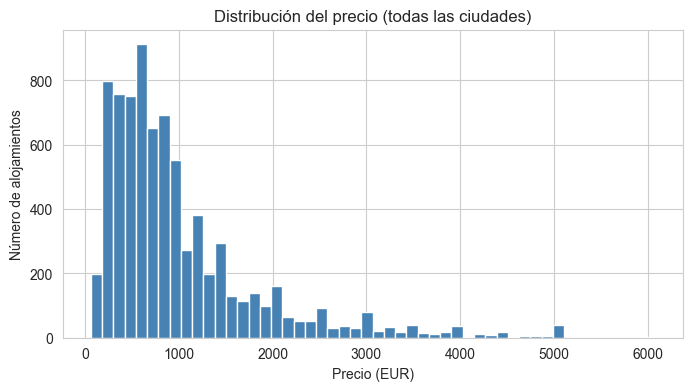

In [15]:
# Distribución del precio: histograma
# (price tiene nulos, se excluyen solo para este gráfico)
plt.figure(figsize=(8, 4))
plt.hist(df["price"].dropna(), bins=50, color="steelblue")
plt.title("Distribución del precio (todas las ciudades)")
plt.xlabel("Precio (EUR)")
plt.ylabel("Número de alojamientos")
plt.show()


El histograma muestra una fuerte asimetría a la derecha: la
mayoría de los precios se concentra en valores bajos/medios,
con una cola larga de alojamientos de precio muy alto (posibles
alojamientos de lujo o valores atípicos).


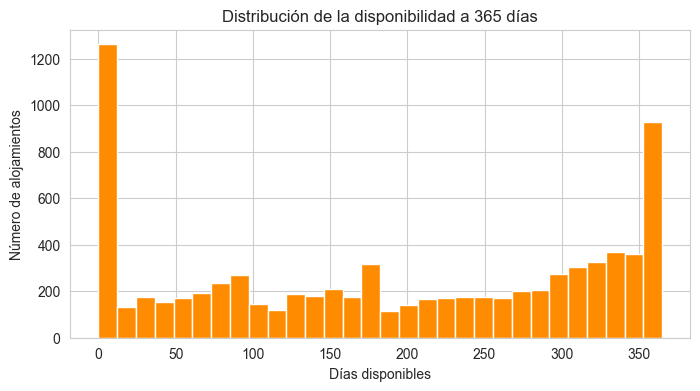

In [16]:
# Distribución de la disponibilidad a 365 días
plt.figure(figsize=(8, 4))
plt.hist(df["availability_365"].dropna(), bins=30, color="darkorange")
plt.title("Distribución de la disponibilidad a 365 días")
plt.xlabel("Días disponibles")
plt.ylabel("Número de alojamientos")
plt.show()


La disponibilidad a 365 días presenta una distribución amplia y no uniforme, con concentraciones en determinados niveles. Esta variable representa días publicados como disponibles y no debe interpretarse directamente como ocupación o demanda real.

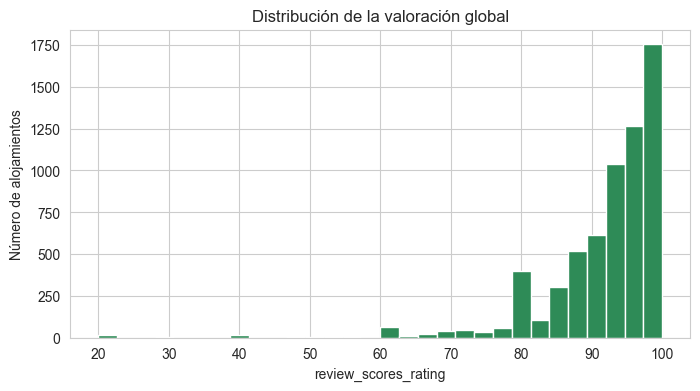

In [17]:
# Distribución de la valoración global (review_scores_rating)
plt.figure(figsize=(8, 4))
plt.hist(
    df["review_scores_rating"].dropna(), bins=30, color="seagreen"
)
plt.title("Distribución de la valoración global")
plt.xlabel("review_scores_rating")
plt.ylabel("Número de alojamientos")
plt.show()


La valoración global está muy concentrada en valores altos
(la mayoría de alojamientos recibe puntuaciones cercanas al
máximo), con una cola de valores bajos menos frecuentes.


### 3.1 Estancia mínima y máxima

`minimum_nights` y `maximum_nights` se analizan como variables generales del dataset.  
En esta fase se revisan su distribución, asimetría y posibles valores extremos.  
La interpretación específica de su relación con ciudades, barrios y potencial de optimización se realizará en el notebook de Marketing.

In [18]:
# Resumen descriptivo de las noches mínimas y máximas
df[["minimum_nights", "maximum_nights"]].describe().T

,count,mean,std,min,25%,50%,75%,max
minimum_nights,8000.0,4.571250,11.807830,1.0,1.0,2.0,4.0,365.0
maximum_nights,8000.0,761.230125,497.949602,1.0,62.0,1125.0,1125.0,1125.0


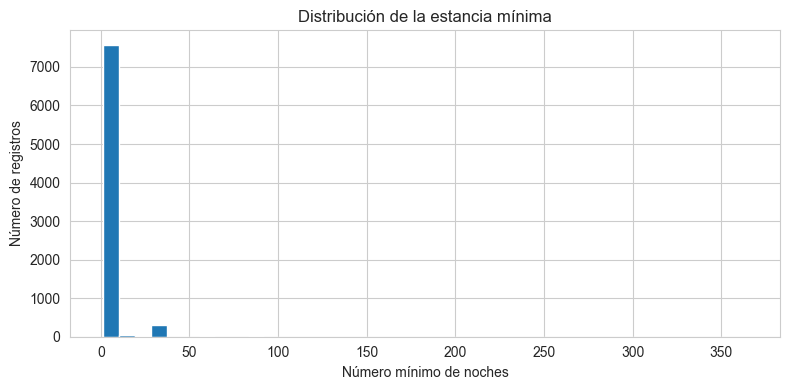

In [19]:
# Distribución de la estancia mínima
plt.figure(figsize=(8, 4))
plt.hist(df["minimum_nights"].dropna(), bins=40)
plt.title("Distribución de la estancia mínima")
plt.xlabel("Número mínimo de noches")
plt.ylabel("Número de registros")
plt.tight_layout()
plt.show()

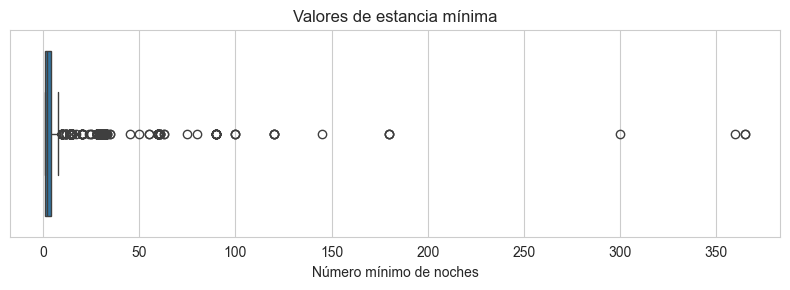

In [20]:
# Boxplot de la estancia mínima
plt.figure(figsize=(8, 3))
sns.boxplot(x=df["minimum_nights"].dropna())
plt.title("Valores de estancia mínima")
plt.xlabel("Número mínimo de noches")
plt.tight_layout()
plt.show()

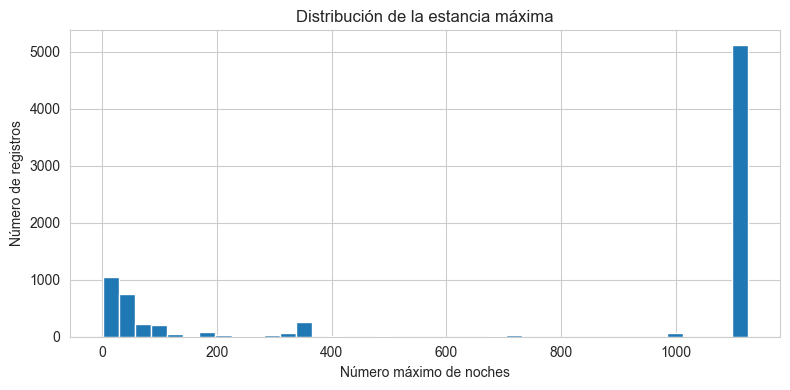

In [21]:
# Distribución de la estancia máxima
plt.figure(figsize=(8, 4))
plt.hist(df["maximum_nights"].dropna(), bins=40)
plt.title("Distribución de la estancia máxima")
plt.xlabel("Número máximo de noches")
plt.ylabel("Número de registros")
plt.tight_layout()
plt.show()

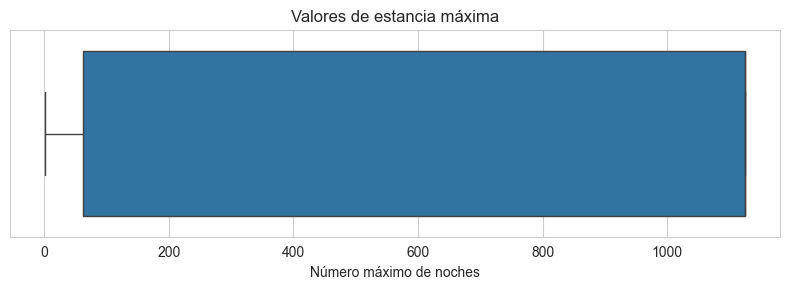

In [22]:
# Boxplot de la estancia máxima
plt.figure(figsize=(8, 3))
sns.boxplot(x=df["maximum_nights"].dropna())
plt.title("Valores de estancia máxima")
plt.xlabel("Número máximo de noches")
plt.tight_layout()
plt.show()

Los histogramas y boxplots muestran que `minimum_nights` y `maximum_nights` presentan distribuciones no uniformes, con asimetría y posibles valores extremos. Estos resultados permiten identificar concentraciones y configuraciones poco frecuentes para su revisión posterior, pero no implican eliminar automáticamente ninguna observación durante la fase de EDA.

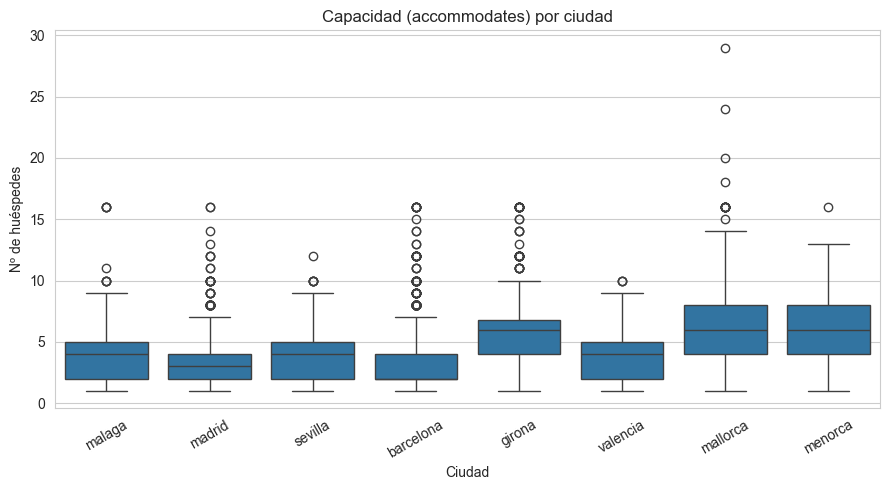

In [23]:
# Boxplot de accommodates por ciudad (capacidad)
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="city", y="accommodates")
plt.title("Capacidad (accommodates) por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Nº de huéspedes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


La capacidad de los alojamientos varía entre ciudades y presenta valores extremos en algunos mercados. Las diferencias específicas se analizarán posteriormente en los notebooks de cada perfil.

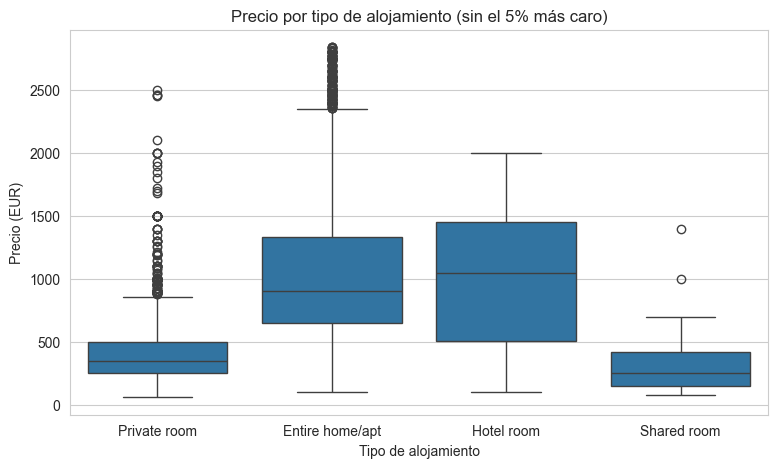

In [24]:
# Boxplot del precio por tipo de alojamiento
# (se excluye el 5% más caro solo para visualizar mejor)
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df[df["price"] < df["price"].quantile(0.95)],
    x="room_type", y="price",
)
plt.title("Precio por tipo de alojamiento (sin el 5% más caro)")
plt.xlabel("Tipo de alojamiento")
plt.ylabel("Precio (EUR)")
plt.show()


Los tipos de alojamiento muestran distribuciones de precio diferentes. Para mejorar la legibilidad del gráfico se excluye únicamente en la visualización el 5 % de precios más altos; estas observaciones permanecen en el dataset.

## 4. Correlaciones exploratorias: Pearson y Spearman

Se mantienen como análisis separados porque tienen objetivos distintos:

- **Pearson** conserva la selección reducida de variables del EDA anterior y permite revisar relaciones lineales de forma clara.
- **Spearman** amplía la exploración a las variables numéricas válidas y es más robusto ante asimetría y valores extremos.

Las correlaciones son exploratorias y se calculan sobre el dataset bruto a nivel de registro.

### Matriz de correlación de Pearson

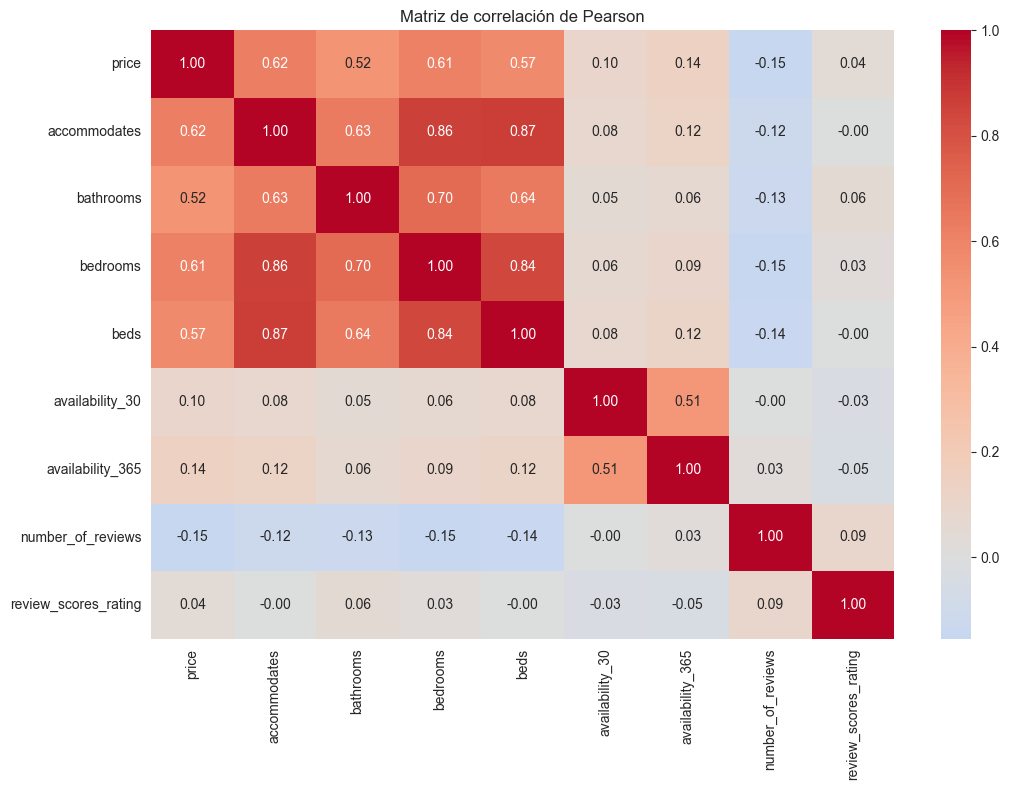

In [25]:
# Pearson: misma selección reducida utilizada en la versión anterior
columnas_pearson = [
    "price",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "availability_30",
    "availability_365",
    "number_of_reviews",
    "review_scores_rating"
]

columnas_pearson = [
    columna for columna in columnas_pearson
    if columna in df.columns and df[columna].nunique(dropna=True) > 1
]

matriz_pearson = df[columnas_pearson].corr(method="pearson")

plt.figure(figsize=(11, 8))
sns.heatmap(
    matriz_pearson,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Matriz de correlación de Pearson")
plt.tight_layout()
plt.show()

Pearson se mantiene con una selección pequeña de variables para facilitar la lectura de relaciones lineales y conservar la comparabilidad con la versión anterior del EDA.

### Matriz de correlación de Spearman

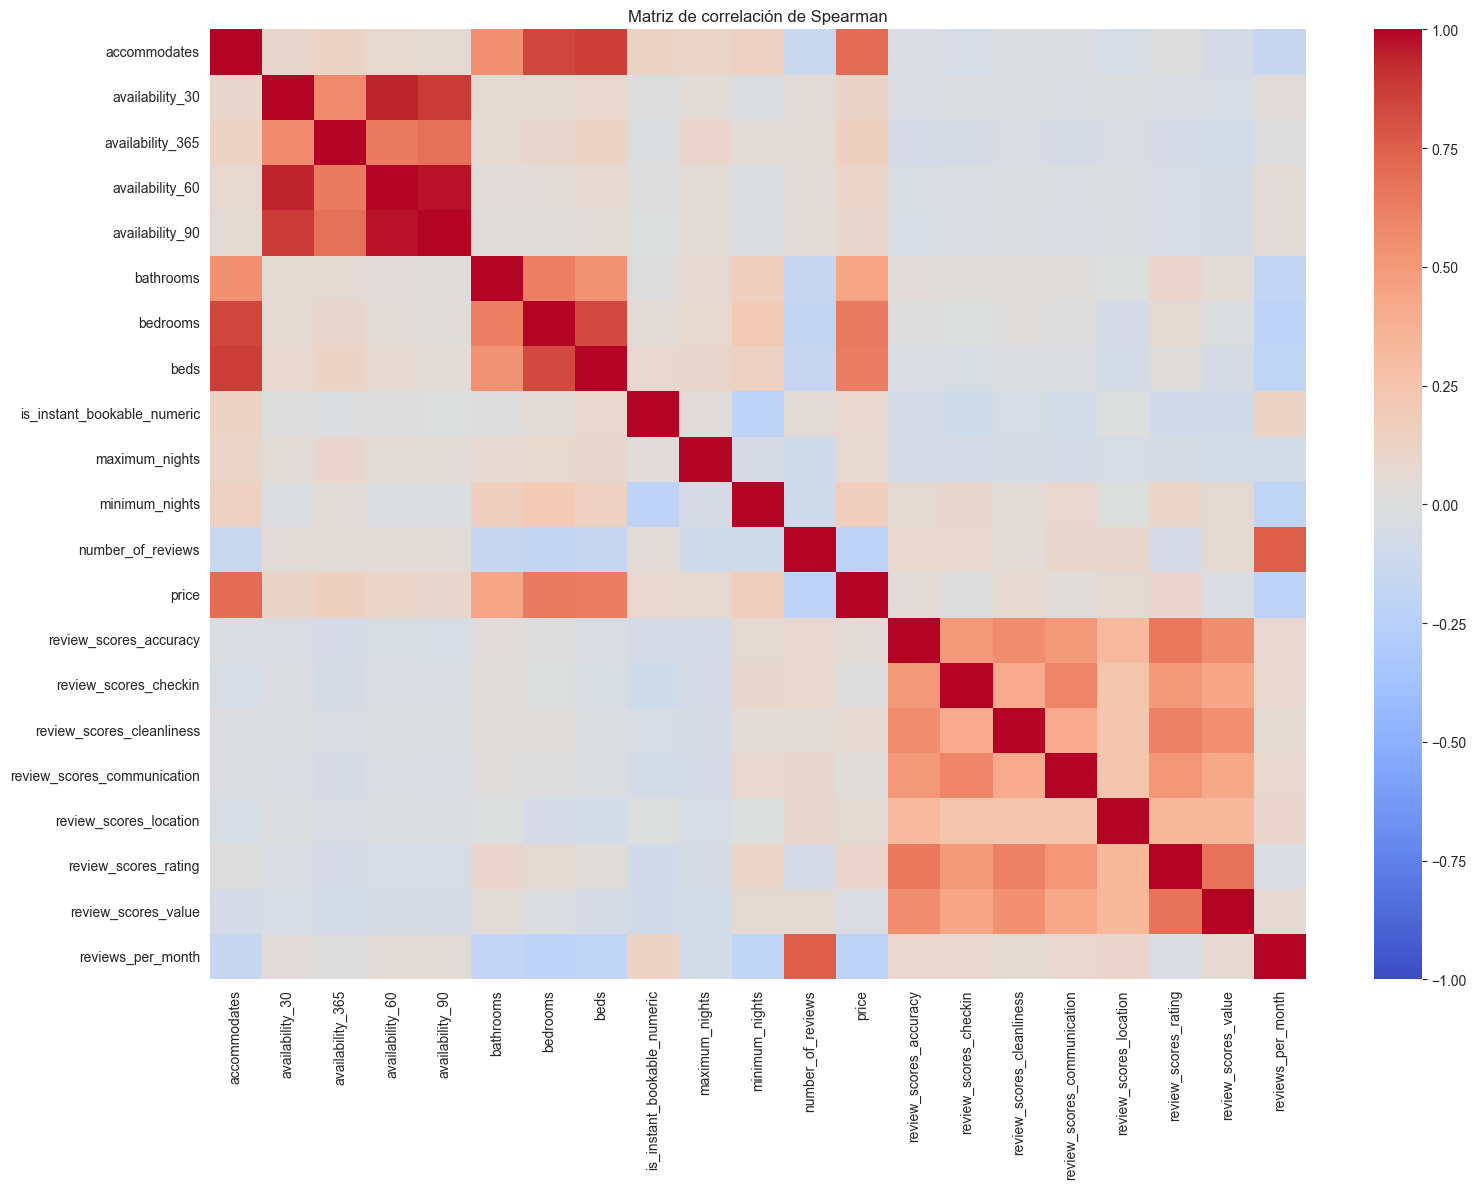

In [26]:
# Spearman: exploración general de variables numéricas válidas
columnas_numericas = (
    df.select_dtypes(include="number")
    .columns
    .difference(["apartment_id", "host_id"])
)

columnas_spearman = [
    columna
    for columna in columnas_numericas
    if df[columna].nunique(dropna=True) > 1
    and not columna.startswith("occupancy_")
]

matriz_spearman = df[columnas_spearman].corr(method="spearman")

plt.figure(figsize=(16, 12))
sns.heatmap(
    matriz_spearman,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Matriz de correlación de Spearman")
plt.tight_layout()
plt.show()

Spearman incluye una selección más amplia y permite detectar relaciones monótonas aunque no sean estrictamente lineales. También reduce la influencia de distribuciones asimétricas y valores extremos.

### Correlaciones de Spearman más fuertes

In [27]:
mascara = np.triu(
    np.ones(matriz_spearman.shape, dtype=bool),
    k=1
)

correlaciones_spearman = (
    matriz_spearman
    .where(mascara)
    .stack()
    .reset_index()
)

correlaciones_spearman.columns = [
    "variable_1",
    "variable_2",
    "correlacion_spearman"
]

correlaciones_spearman["valor_absoluto"] = (
    correlaciones_spearman["correlacion_spearman"].abs()
)

correlaciones_spearman.sort_values(
    "valor_absoluto",
    ascending=False
).head(15).round(3)

,variable_1,variable_2,correlacion_spearman,valor_absoluto
67,availability_60,availability_90,0.970,0.970
24,availability_30,availability_60,0.938,0.938
25,availability_30,availability_90,0.877,0.877
7,accommodates,beds,0.868,0.868
6,accommodates,bedrooms,0.836,0.836
133,bedrooms,beds,0.828,0.828
251,number_of_reviews,reviews_per_month,0.759,0.759
12,accommodates,price,0.699,0.699
46,availability_365,availability_90,0.682,0.682
397,review_scores_rating,review_scores_value,0.678,0.678


## 5. Variables categóricas

In [28]:
# Distribución de room_type
df["room_type"].value_counts()


room_type
Entire home/apt    5680
Private room       2215
Hotel room           54
Shared room          51
Name: count, dtype: int64

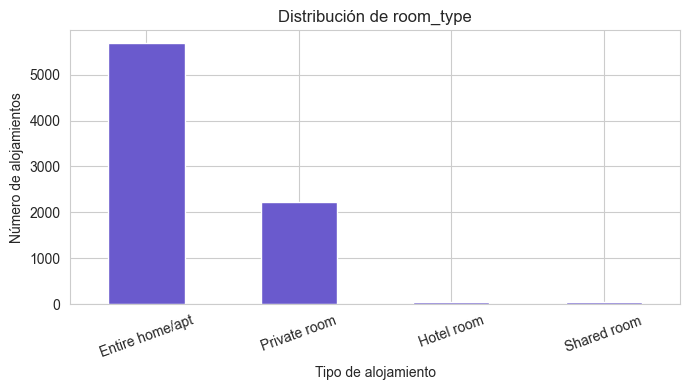

In [29]:
plt.figure(figsize=(7, 4))
df["room_type"].value_counts().plot(kind="bar", color="slateblue")
plt.title("Distribución de room_type")
plt.xlabel("Tipo de alojamiento")
plt.ylabel("Número de alojamientos")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [30]:
# Distribución de is_instant_bookable
df["is_instant_bookable"].value_counts()


is_instant_bookable
VERDADERO    4439
FALSO        3561
Name: count, dtype: int64

In [31]:
# Distribución de has_availability (incluye los nulos)
df["has_availability"].value_counts(dropna=False)


has_availability
VERDADERO    7450
NaN           550
Name: count, dtype: int64

`has_availability` solo tiene un valor posible (VERDADERO) y
un bloque de nulos (~550 registros): no hay ningún registro con
valor FALSO, lo cual sigue siendo la anomalía ya reportada a
IT en Data Understanding.


In [32]:
# Registros y alojamientos únicos por ciudad
resumen_ciudad = (
    df.groupby("city", dropna=False)
    .agg(
        registros=("apartment_id", "size"),
        alojamientos_unicos=("apartment_id", "nunique"),
    )
    .sort_values("alojamientos_unicos", ascending=False)
)

total_alojamientos = df["apartment_id"].nunique()

resumen_ciudad["porcentaje_alojamientos"] = (
    resumen_ciudad["alojamientos_unicos"]
    / total_alojamientos
    * 100
).round(2)

resumen_ciudad


,registros,alojamientos_unicos,porcentaje_alojamientos
city,,,
barcelona,2358,2261,29.39
madrid,1703,1645,21.38
mallorca,1318,1265,16.44
girona,1242,1198,15.57
sevilla,428,403,5.24
malaga,408,394,5.12
valencia,372,360,4.68
menorca,171,167,2.17


## 6. Conclusiones y próximos pasos

- El nombre del dataset está centralizado en una única sección de parámetros para facilitar su actualización semanal.

- Los `apartment_id` repetidos corresponden a snapshots temporales y no a duplicados exactos. Los análisis posteriores deberán utilizar el último registro disponible de cada alojamiento.

- El precio presenta una distribución claramente asimétrica hacia la derecha, mientras que las valoraciones generales se concentran en puntuaciones altas.

- `minimum_nights` y `maximum_nights` presentan distribuciones no uniformes, con asimetría y posibles valores extremos. Estos patrones deberán revisarse según el contexto del análisis y no implican eliminar automáticamente ninguna observación.

- La tabla basada en IQR identifica posibles valores atípicos para su posterior validación, pero no implica su eliminación automática.

- El resumen por ciudad diferencia entre registros y alojamientos únicos, evitando contar varios snapshots del mismo alojamiento como unidades independientes.

- Pearson y Spearman se utilizan de forma complementaria: Pearson explora relaciones lineales y Spearman explora relaciones monotónicas y es más robusto ante la asimetría y los valores extremos.

- Las correlaciones más altas aparecen entre los distintos horizontes de disponibilidad y entre las variables de capacidad del alojamiento. También se observa una asociación positiva entre el precio y la capacidad, así como entre la puntuación general y algunos componentes de la experiencia.

- Las preguntas de negocio específicas se desarrollarán en los notebooks de Marketing, Operaciones y Experiencia del Cliente.
